# Inverse mixed PINN for 2D linear elastostatics

The goal is to approximate two displacement components and three stress components on

$$
\Omega=(0,1)^2,
$$

while Young's modulus $E$ and Poisson's ratio $\nu$ are unknown trainable parameters. Following the independent-network architecture, five separate neural networks approximate

$$
u_{1,\theta},\qquad u_{2,\theta},\qquad \sigma_{xx,\theta},\qquad \sigma_{yy,\theta},\qquad \sigma_{xy,\theta}.
$$

Their outputs are collected as

$$
\mathbf q_\theta(x,y)=
\begin{bmatrix}
u_{1,\theta} & u_{2,\theta} & \sigma_{xx,\theta} & \sigma_{yy,\theta} & \sigma_{xy,\theta}
\end{bmatrix}^{\mathsf T}.
$$

For the synthetic inverse experiment, the hidden true values are $E_{\mathrm{true}}=1$ and $\nu_{\mathrm{true}}=1/4$. The exact displacement is

$$
\mathbf u_{\mathrm{exact}}(x,y)=a
\begin{bmatrix}
\cos x-y^2\\
2\sin x+y
\end{bmatrix},
\qquad a=0.005.
$$

## Strong formulation

The infinitesimal-strain tensor, constitutive law, and equilibrium equation are

$$
\boldsymbol\varepsilon(\mathbf u)=\frac12\left(\nabla\mathbf u+\nabla\mathbf u^{\mathsf T}\right),
\qquad
\boldsymbol\sigma=\lambda\operatorname{tr}(\boldsymbol\varepsilon)\mathbf I+2\mu\boldsymbol\varepsilon,
\qquad
\nabla\cdot\boldsymbol\sigma+\mathbf b=\mathbf0.
$$

During training, the Lamé parameters are computed from the identified values:

$$
\lambda_\theta=\frac{E_\theta\nu_\theta}{(1+\nu_\theta)(1-2\nu_\theta)},
\qquad
\mu_\theta=\frac{E_\theta}{2(1+\nu_\theta)}.
$$

Boundary conditions are not included in the loss. Observations of all five fields are always used in this inverse problem and may be either exact or Gaussian-noisy.


## 1. Library imports


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


## 2. Configuration

- Observations of all five fields are always included in the inverse loss.
- `USE_NOISY_DATA = False` uses exact observations.
- `USE_NOISY_DATA = True` adds independent zero-mean Gaussian noise with standard deviation $s_{\mathrm{noise}}=0.02a$.
- Adam uses mini-batches of PDE points, whereas L-BFGS uses a fixed full batch.
- $E$ and $\nu$ are identified simultaneously with all neural-network parameters.


In [24]:
USE_NOISY_DATA = True

E_TRUE, NU_TRUE = 1.0, 0.25
INITIAL_E, INITIAL_NU = 5.0, 0.1
LAMBDA_TRUE = E_TRUE * NU_TRUE / ((1.0 + NU_TRUE) * (1.0 - 2.0 * NU_TRUE))
MU_TRUE = E_TRUE / (2.0 * (1.0 + NU_TRUE))
AMPLITUDE = 0.005
NOISE_STD = 0.02 * AMPLITUDE

N_PDE_TRAIN=3000
N_PDE_VALIDATION= 1500
N_PDE_TEST = 1500
PDE_BATCH_SIZE = 100
N_DATA_TRAIN = 30
N_DATA_VALIDATION = 7
N_DATA_TEST = 7
EPOCHS = 2000
LBFGS_EPOCHS = 100
LR = 1e-3
SEED = 42

torch.manual_seed(SEED)
print(f"True E = {E_TRUE:.6f}, true nu = {NU_TRUE:.6f}")
print(f"Initial E = {INITIAL_E:.6f}, initial nu = {INITIAL_NU:.6f}")
print(f"Data mode: {'noisy' if USE_NOISY_DATA else 'exact'}, noise standard deviation = {NOISE_STD:.6e}")


True E = 1.000000, true nu = 0.250000
Initial E = 5.000000, initial nu = 0.100000
Data mode: noisy, noise standard deviation = 1.000000e-04


## 3. Exact displacement, stress, and body force


In [25]:
def exact_displacement(xy):
    x, y = xy[:, 0:1], xy[:, 1:2]
    u1 = AMPLITUDE * (torch.cos(x) - y**2)
    u2 = AMPLITUDE * (2.0 * torch.sin(x) + y)
    return torch.cat((u1, u2), dim=1)

def exact_stress(xy):
    x, y, a = xy[:, 0:1], xy[:, 1:2], AMPLITUDE
    eps_xx, eps_yy, eps_xy = -a * torch.sin(x), a * torch.ones_like(x), a * (torch.cos(x) - y)
    trace_eps = eps_xx + eps_yy
    sigma_xx = LAMBDA_TRUE * trace_eps + 2.0 * MU_TRUE * eps_xx
    sigma_yy = LAMBDA_TRUE * trace_eps + 2.0 * MU_TRUE * eps_yy
    sigma_xy = 2.0 * MU_TRUE * eps_xy
    return torch.cat((sigma_xx, sigma_yy, sigma_xy), dim=1)

def exact_fields(xy):
    return torch.cat((exact_displacement(xy), exact_stress(xy)), dim=1)

def body_force(xy):
    x, a = xy[:, 0:1], AMPLITUDE
    b1 = a * (LAMBDA_TRUE + 2.0 * MU_TRUE) * torch.cos(x) + 2.0 * MU_TRUE * a
    b2 = 2.0 * MU_TRUE * a * torch.sin(x)
    return torch.cat((b1, b2), dim=1)


## 4. Five independent neural networks and trainable material parameters

One independent scalar-output network is used for each field:

$$
\mathcal N_{u_1},\qquad \mathcal N_{u_2},\qquad \mathcal N_{\sigma_{xx}},\qquad \mathcal N_{\sigma_{yy}},\qquad \mathcal N_{\sigma_{xy}}.
$$

The networks do not share weights or biases. Each has five hidden layers with 20 neurons per layer and the $\tanh$ activation function. The scalars $E_\theta$ and $\nu_\theta$ are stored as `nn.Parameter`, so both optimizers update them together with the parameters of all five networks.


In [26]:
class FieldNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 20),
                                  nn.Tanh(), 
                                  nn.Linear(20, 20), 
                                  nn.Tanh(), 
                                  nn.Linear(20, 20), 
                                  nn.Tanh(), 
                                  nn.Linear(20, 20), 
                                  nn.Tanh(), 
                                  nn.Linear(20, 20), 
                                  nn.Tanh(), 
                                  nn.Linear(20, 1))

    def forward(self, xy):
        return self.net(xy)

class IndependentMixedPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.u1_network = FieldNetwork()
        self.u2_network = FieldNetwork()
        self.sigma_xx_network = FieldNetwork()
        self.sigma_yy_network = FieldNetwork()
        self.sigma_xy_network = FieldNetwork()
        self.young_modulus = nn.Parameter(torch.tensor(INITIAL_E))
        self.poisson_ratio = nn.Parameter(torch.tensor(INITIAL_NU))

    def forward(self, xy):
        u1 = self.u1_network(xy)
        u2 = self.u2_network(xy)
        sigma_xx = self.sigma_xx_network(xy)
        sigma_yy = self.sigma_yy_network(xy)
        sigma_xy = self.sigma_xy_network(xy)
        return torch.cat((u1, u2, sigma_xx, sigma_yy, sigma_xy), dim=1)

model = IndependentMixedPINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)


## 5. Training, validation, and test points

The PDE training, validation, and test points form three separately shifted uniform Cartesian grids. The supervised data locations are generated independently at random. Observations are always included in the inverse loss and are either exact or Gaussian-noisy according to `USE_NOISY_DATA`. Boundary points are not generated because boundary conditions are excluded from the loss.


In [27]:
def uniform_grid(n_points, offset_x=0.5, offset_y=0.5):
    n_x = int(np.sqrt(n_points))
    while n_points % n_x != 0:
        n_x -= 1
    n_y = n_points // n_x
    x = (torch.arange(n_x, dtype=torch.float32) + offset_x) / n_x
    y = (torch.arange(n_y, dtype=torch.float32) + offset_y) / n_y
    X, Y = torch.meshgrid(x, y, indexing='xy')
    return torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)

def observed_fields(xy, seed):
    exact = exact_fields(xy)
    if not USE_NOISY_DATA:
        return exact
    generator = torch.Generator().manual_seed(seed)
    noise = NOISE_STD * torch.randn(exact.shape, generator=generator, dtype=exact.dtype)
    return exact + noise

pde_train_generator = torch.Generator().manual_seed(SEED + 1)
xy_pde_train = uniform_grid(N_PDE_TRAIN, 0.50, 0.50)
xy_pde_validation = uniform_grid(N_PDE_VALIDATION, 0.25, 0.25)
xy_pde_test = uniform_grid(N_PDE_TEST, 0.75, 0.75)
pde_loader = DataLoader(TensorDataset(xy_pde_train), batch_size=PDE_BATCH_SIZE, shuffle=True, generator=pde_train_generator)

xy_data_train = torch.rand(N_DATA_TRAIN, 2, generator=torch.Generator().manual_seed(SEED + 3))
xy_data_validation = torch.rand(N_DATA_VALIDATION, 2, generator=torch.Generator().manual_seed(SEED + 11))
xy_data_test = torch.rand(N_DATA_TEST, 2, generator=torch.Generator().manual_seed(SEED + 4))
fields_data_train = observed_fields(xy_data_train, SEED + 20)
fields_data_validation = observed_fields(xy_data_validation, SEED + 21)
fields_data_test = observed_fields(xy_data_test, SEED + 22)


## 6. Equilibrium and constitutive residuals

Because the stress components are approximated independently, the physics loss contains equilibrium and constitutive residuals:

$$
\mathbf r_{\mathrm{eq},\theta}=\nabla\cdot\boldsymbol\sigma_\theta+\mathbf b,
\qquad
\mathbf r_{\mathrm{const},\theta}=\boldsymbol\sigma_\theta-\left[\lambda_\theta\operatorname{tr}(\boldsymbol\varepsilon(\mathbf u_\theta))\mathbf I+2\mu_\theta\boldsymbol\varepsilon(\mathbf u_\theta)\right].
$$

The complete training loss is

$$
\mathcal L=\mathcal L_{\mathrm{eq}}+\mathcal L_{\mathrm{const}}+\mathcal L_{\mathrm{data}},
$$

with no boundary-condition loss. The data term is always present; `USE_NOISY_DATA` only determines whether its observations are exact or noisy.


In [28]:
def split_prediction(prediction):
    return prediction[:, 0:1], prediction[:, 1:2], prediction[:, 2:3], prediction[:, 3:4], prediction[:, 4:5]

def lame_parameters():
    E, nu = model.young_modulus, model.poisson_ratio
    lame_lambda = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
    lame_mu = E / (2.0 * (1.0 + nu))
    return lame_lambda, lame_mu

def constitutive_stress_from_displacement(xy, u1, u2, create_graph):
    grad_u1 = torch.autograd.grad(u1, xy, grad_outputs=torch.ones_like(u1), create_graph=create_graph, retain_graph=True)[0]
    grad_u2 = torch.autograd.grad(u2, xy, grad_outputs=torch.ones_like(u2), create_graph=create_graph, retain_graph=True)[0]
    eps_xx, eps_yy = grad_u1[:, 0:1], grad_u2[:, 1:2]
    eps_xy = 0.5 * (grad_u1[:, 1:2] + grad_u2[:, 0:1])
    trace_eps = eps_xx + eps_yy
    lame_lambda, lame_mu = lame_parameters()
    sigma_xx = lame_lambda * trace_eps + 2.0 * lame_mu * eps_xx
    sigma_yy = lame_lambda * trace_eps + 2.0 * lame_mu * eps_yy
    sigma_xy = 2.0 * lame_mu * eps_xy
    return torch.cat((sigma_xx, sigma_yy, sigma_xy), dim=1)

def mixed_residuals(xy, training=True):
    xy = xy.detach().clone().requires_grad_(True)
    prediction = model(xy)
    u1, u2, sigma_xx, sigma_yy, sigma_xy = split_prediction(prediction)
    predicted_stress = torch.cat((sigma_xx, sigma_yy, sigma_xy), dim=1)
    residual_constitutive = predicted_stress - constitutive_stress_from_displacement(xy, u1, u2, create_graph=training)
    grad_sigma_xx = torch.autograd.grad(sigma_xx, xy, grad_outputs=torch.ones_like(sigma_xx), create_graph=training, retain_graph=True)[0]
    grad_sigma_yy = torch.autograd.grad(sigma_yy, xy, grad_outputs=torch.ones_like(sigma_yy), create_graph=training, retain_graph=True)[0]
    grad_sigma_xy = torch.autograd.grad(sigma_xy, xy, grad_outputs=torch.ones_like(sigma_xy), create_graph=training, retain_graph=True)[0]
    b = body_force(xy)
    residual_1 = grad_sigma_xx[:, 0:1] + grad_sigma_xy[:, 1:2] + b[:, 0:1]
    residual_2 = grad_sigma_xy[:, 0:1] + grad_sigma_yy[:, 1:2] + b[:, 1:2]
    return torch.cat((residual_1, residual_2), dim=1), residual_constitutive, prediction

def compute_losses(xy_pde):
    residual_eq, residual_const, _ = mixed_residuals(xy_pde, training=True)
    loss_equilibrium = torch.mean(residual_eq**2)
    loss_constitutive = torch.mean(residual_const**2)
    loss_data = torch.mean((model(xy_data_train) - fields_data_train)**2)
    loss = loss_equilibrium + loss_constitutive + loss_data
    return loss, loss_equilibrium, loss_constitutive, loss_data

def compute_validation_losses():
    residual_eq, residual_const, _ = mixed_residuals(xy_pde_validation, training=False)
    loss_validation_equilibrium = torch.mean(residual_eq.detach()**2)
    loss_validation_constitutive = torch.mean(residual_const.detach()**2)
    with torch.no_grad():
        loss_validation_data = torch.mean((model(xy_data_validation) - fields_data_validation)**2)
    loss_validation = loss_validation_equilibrium + loss_validation_constitutive + loss_validation_data
    return loss_validation, loss_validation_equilibrium, loss_validation_constitutive, loss_validation_data


## 7. Training, validation, and best-epoch selection


In [29]:
loss_history, equilibrium_loss_history, constitutive_loss_history, data_loss_history = [], [], [], []
validation_loss_history, validation_equilibrium_loss_history = [], []
validation_constitutive_loss_history, validation_data_loss_history = [], []
E_history, nu_history = [], []
ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS
best_validation_loss, best_epoch, best_model_state = float("inf"), None, None

def clone_model_state():
    return {name: value.detach().clone() for name, value in model.state_dict().items()}

def update_validation_checkpoint(epoch):
    global best_validation_loss, best_epoch, best_model_state
    validation, validation_eq, validation_const, validation_data = compute_validation_losses()
    values = validation.item(), validation_eq.item(), validation_const.item(), validation_data.item()
    validation_loss_history.append(values[0])
    validation_equilibrium_loss_history.append(values[1])
    validation_constitutive_loss_history.append(values[2])
    validation_data_loss_history.append(values[3])
    if best_model_state is None or values[0] < best_validation_loss:
        best_validation_loss, best_epoch, best_model_state = values[0], epoch, clone_model_state()
    return values[0]

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_adam, mode="min", factor=0.5, patience=200)

for epoch in range(ADAM_EPOCHS):
    epoch_sums = np.zeros(4)
    for (xy_pde_batch,) in pde_loader:
        optimizer_adam.zero_grad()
        losses = compute_losses(xy_pde_batch)
        losses[0].backward()
        optimizer_adam.step()
        epoch_sums += np.array([value.detach().item() for value in losses])
    loss_value, equilibrium_value, constitutive_value, data_value = epoch_sums / len(pde_loader)
    scheduler.step(loss_value)
    loss_history.append(loss_value)
    equilibrium_loss_history.append(equilibrium_value)
    constitutive_loss_history.append(constitutive_value)
    data_loss_history.append(data_value)
    E_history.append(model.young_modulus.detach().item())
    nu_history.append(model.poisson_ratio.detach().item())
    validation_value = update_validation_checkpoint(epoch)
    if epoch % 500 == 0:
        print(f"Adam | epoch {epoch:5d} | loss={loss_value:.6e} | eq={equilibrium_value:.6e} | const={constitutive_value:.6e} | data={data_value:.6e} | validation={validation_value:.6e} | E={E_history[-1]:.6f} | nu={nu_history[-1]:.6f}")

print(f"Switching from Adam to full-batch L-BFGS at epoch {ADAM_EPOCHS}.")
optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=20, history_size=10, line_search_fn="strong_wolfe")

for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch
    def closure():
        optimizer_lbfgs.zero_grad()
        loss = compute_losses(xy_pde_train)[0]
        loss.backward()
        return loss
    optimizer_lbfgs.step(closure)
    loss, loss_eq, loss_const, loss_data = compute_losses(xy_pde_train)
    loss_history.append(loss.detach().item())
    equilibrium_loss_history.append(loss_eq.detach().item())
    constitutive_loss_history.append(loss_const.detach().item())
    data_loss_history.append(loss_data.detach().item())
    E_history.append(model.young_modulus.detach().item())
    nu_history.append(model.poisson_ratio.detach().item())
    validation_value = update_validation_checkpoint(epoch)
    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        print(f"L-BFGS | epoch {epoch:5d} | loss={loss.item():.6e} | eq={loss_eq.item():.6e} | const={loss_const.item():.6e} | data={loss_data.item():.6e} | validation={validation_value:.6e} | E={E_history[-1]:.6f} | nu={nu_history[-1]:.6f}")

last_model_state = clone_model_state()
model.load_state_dict(best_model_state)
model.eval()
print(f"Best epoch: {best_epoch}, best validation loss: {best_validation_loss:.6e}")
print(f"Identified E: {model.young_modulus.item():.8f}, identified nu: {model.poisson_ratio.item():.8f}")


Adam | epoch     0 | loss=8.877918e-03 | eq=9.384727e-05 | const=4.177458e-03 | data=4.606613e-03 | validation=2.854498e-04 | E=4.992077 | nu=0.086595
Adam | epoch   500 | loss=5.949326e-07 | eq=1.996607e-09 | const=1.001189e-07 | data=4.928172e-07 | validation=8.148814e-07 | E=4.542594 | nu=0.133890
Adam | epoch  1000 | loss=7.147011e-08 | eq=1.050083e-09 | const=2.499511e-08 | data=4.542491e-08 | validation=3.358502e-08 | E=1.012694 | nu=0.244645
Adam | epoch  1500 | loss=1.465996e-08 | eq=2.428792e-10 | const=2.614249e-09 | data=1.180283e-08 | validation=1.875924e-08 | E=0.996974 | nu=0.249616
Switching from Adam to full-batch L-BFGS at epoch 1900.
L-BFGS | epoch  1900 | loss=1.010995e-08 | eq=1.237407e-10 | const=4.705387e-10 | data=9.515671e-09 | validation=1.333833e-08 | E=0.996822 | nu=0.250495
L-BFGS | epoch  1950 | loss=1.010995e-08 | eq=1.237407e-10 | const=4.705387e-10 | data=9.515671e-09 | validation=1.333833e-08 | E=0.996822 | nu=0.250495
L-BFGS | epoch  1999 | loss=1.0109

## 8. Testing the restored best model on independent points


In [30]:
model.eval()
residual_eq_test, residual_const_test, prediction_test = mixed_residuals(xy_pde_test, training=False)
exact_test, prediction_test = exact_fields(xy_pde_test).detach(), prediction_test.detach()
u_prediction, u_exact = prediction_test[:, 0:2], exact_test[:, 0:2]
stress_prediction, stress_exact = prediction_test[:, 2:5], exact_test[:, 2:5]

def r2_score(prediction, exact):
    ss_res = torch.sum((prediction - exact)**2)
    ss_tot = torch.sum((exact - torch.mean(exact))**2)
    return (1.0 - ss_res / ss_tot).item()

def relative_l2(prediction, exact):
    return (torch.linalg.vector_norm(prediction - exact) / torch.linalg.vector_norm(exact)).item()

r2_u, relative_l2_u = r2_score(u_prediction, u_exact), relative_l2(u_prediction, u_exact)
r2_stress, relative_l2_stress = r2_score(stress_prediction, stress_exact), relative_l2(stress_prediction, stress_exact)
data_mode = "noisy" if USE_NOISY_DATA else "exact"
metrics = {"data_mode": data_mode, "noise_standard_deviation": NOISE_STD, "best_epoch": best_epoch,
            "best_validation_loss": best_validation_loss, "R2_displacement": r2_u, "relative_L2_displacement": relative_l2_u,
             "R2_stress": r2_stress, "relative_L2_stress": relative_l2_stress}

print("=" * 72)
print("TEST RESULTS OF THE RESTORED BEST INVERSE MIXED 2D PINN")
print("=" * 72)
print(f"Data mode:                          {data_mode}")
print(f"Noise standard deviation:           {NOISE_STD:.6e}")
print(f"Best epoch:                         {best_epoch}")
print(f"R2 displacement:                    {r2_u:.8f}")
print(f"Relative L2 displacement error:     {relative_l2_u:.6e}")
print(f"R2 stress:                          {r2_stress:.8f}")
print(f"Relative L2 stress error:           {relative_l2_stress:.6e}")
print("=" * 72)
metrics


TEST RESULTS OF THE RESTORED BEST INVERSE MIXED 2D PINN
Data mode:                          noisy
Noise standard deviation:           1.000000e-04
Best epoch:                         1854
R2 displacement:                    0.99969751
Relative L2 displacement error:     9.815494e-03
R2 stress:                          0.99965000
Relative L2 stress error:           1.537444e-02


{'data_mode': 'noisy',
 'noise_standard_deviation': 0.0001,
 'best_epoch': 1854,
 'best_validation_loss': 1.2443516439475388e-08,
 'R2_displacement': 0.9996975064277649,
 'relative_L2_displacement': 0.00981549359858036,
 'R2_stress': 0.9996500015258789,
 'relative_L2_stress': 0.015374436974525452}

## 9. Visualization functions

The plots show the point sets, exact fields, best and last epochs, normalized absolute errors, residuals, training and validation losses, and the histories of the identified material parameters.


In [31]:
def make_grid(n=101, requires_grad=False):
    values = torch.linspace(0.0, 1.0, n)
    X, Y = torch.meshgrid(values, values, indexing="xy")
    xy = torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)
    if requires_grad:
        xy.requires_grad_(True)
    return X.numpy(), Y.numpy(), xy

def fields_from_state(state, xy):
    current_state = clone_model_state()
    model.load_state_dict(state)
    model.eval()
    with torch.no_grad():
        fields = model(xy).detach().clone()
    model.load_state_dict(current_state)
    return fields

def plot_points():
    train, validation, test = xy_pde_train.detach(), xy_pde_validation.detach(), xy_pde_test.detach()
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].scatter(train[:, 0], train[:, 1], s=10, alpha=0.5, label=f"PDE train ({len(train)})")
    axes[0].scatter(validation[:, 0], validation[:, 1], s=9, marker="s", alpha=0.35, label=f"PDE validation ({len(validation)})")
    axes[0].scatter(test[:, 0], test[:, 1], s=8, marker="x", alpha=0.25, label=f"PDE test ({len(test)})")
    axes[0].set(title="Collocation points", xlabel="x", ylabel="y")
    axes[0].set_aspect("equal")
    axes[0].legend()
    axes[0].grid()
    axes[1].scatter(xy_data_train[:, 0], xy_data_train[:, 1], s=20, label=f"data train ({len(xy_data_train)})")
    axes[1].scatter(xy_data_validation[:, 0], xy_data_validation[:, 1], s=16, marker="s", color="tab:green", label=f"data validation ({len(xy_data_validation)})")
    axes[1].scatter(xy_data_test[:, 0], xy_data_test[:, 1], s=16, marker="x", color="tab:orange", label=f"data test ({len(xy_data_test)})")
    axes[1].set(title=f"Supervised data ({'noisy' if USE_NOISY_DATA else 'exact'})", xlabel="x", ylabel="y")
    axes[1].set_aspect("equal")
    axes[1].legend()
    axes[1].grid()
    fig.tight_layout()
    plt.savefig("mixed_pinn_points.pdf", bbox_inches="tight")
    plt.show()

def plot_field_comparison(field_indices, names, filename, n=101):
    X, Y, xy = make_grid(n)
    with torch.no_grad():
        exact_tensor = exact_fields(xy)
    best_tensor = fields_from_state(best_model_state, xy)
    eps = torch.finfo(exact_tensor.dtype).eps
    scales = torch.amax(torch.abs(exact_tensor), dim=0, keepdim=True).clamp_min(eps)
    error_tensor = torch.abs(best_tensor - exact_tensor) / scales
    exact = exact_tensor.numpy().reshape(n, n, 5)
    best = best_tensor.numpy().reshape(n, n, 5)
    error = error_tensor.numpy().reshape(n, n, 5)
    nrows = len(field_indices)
    fig, axes = plt.subplots(nrows, 3, figsize=(15, 4.2 * nrows))
    if nrows == 1:
        axes = axes.reshape(1, 3)
    for row, (field_index, name) in enumerate(zip(field_indices, names)):
        exact_field = exact[:, :, field_index]
        best_field = best[:, :, field_index]
        error_field = error[:, :, field_index]
        field_min = min(np.min(exact_field), np.min(best_field))
        field_max = max(np.max(exact_field), np.max(best_field))
        if field_min < 0.0 < field_max:
            limit = max(abs(field_min), abs(field_max))
            field_min, field_max = -limit, limit
        if np.isclose(field_min, field_max):
            field_max = field_min + np.finfo(float).eps
        common_levels = np.linspace(field_min, field_max, 41)
        exact_image = axes[row, 0].contourf(X, Y, exact_field, levels=common_levels, cmap="coolwarm")
        best_image = axes[row, 1].contourf(X, Y, best_field, levels=common_levels, cmap="coolwarm")
        error_max = max(np.max(error_field), np.finfo(float).eps)
        error_levels = np.linspace(0.0, error_max, 41)
        error_image = axes[row, 2].contourf(X, Y, error_field, levels=error_levels, cmap="viridis")
        titles = [f"Exact {name}", f"Best epoch {name}", f"Relative absolute error {name}"]
        for axis, title in zip(axes[row], titles):
            axis.set(title=title, xlabel="x", ylabel="y")
            axis.set_aspect("equal")
        fig.colorbar(exact_image, ax=axes[row, 0], fraction=0.046, pad=0.04)
        fig.colorbar(best_image, ax=axes[row, 1], fraction=0.046, pad=0.04)
        fig.colorbar(error_image, ax=axes[row, 2], fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.savefig(filename, bbox_inches="tight")
    plt.show()

def plot_displacement(n=101):
    plot_field_comparison([0, 1], ["u1", "u2"], "mixed_pinn_displacement.pdf", n)

def plot_stress(n=101):
    plot_field_comparison([2, 3, 4], ["sigma_xx", "sigma_yy", "sigma_xy"], "mixed_pinn_stress.pdf", n)

def plot_deformed_domain(scale=1.0, n_lines=11, n_points=101):
    fig, ax = plt.subplots(figsize=(8, 8))
    coordinates, line_values = torch.linspace(0.0, 1.0, n_points), torch.linspace(0.0, 1.0, n_lines)
    first_line = True
    for value in line_values:
        horizontal = torch.stack((coordinates, value * torch.ones_like(coordinates)), dim=1)
        vertical = torch.stack((value * torch.ones_like(coordinates), coordinates), dim=1)
        for line in (horizontal, vertical):
            with torch.no_grad():
                exact_deformed = line + scale * exact_displacement(line)
                pinn_deformed = line + scale * model(line)[:, 0:2]
            ax.plot(line[:, 0], line[:, 1], color="gray", linestyle=":", alpha=0.4, label="original" if first_line else None)
            ax.plot(exact_deformed[:, 0], exact_deformed[:, 1], "r--", alpha=0.8, label="exact deformation" if first_line else None)
            ax.plot(pinn_deformed[:, 0], pinn_deformed[:, 1], color="tab:blue", alpha=0.8, label="best PINN" if first_line else None)
            first_line = False
    ax.set(title=f"Deformed domain, displacement scale = {scale}", xlabel="x", ylabel="y")
    ax.set_aspect("equal")
    ax.legend()
    ax.grid()
    fig.tight_layout()
    plt.savefig("mixed_pinn_deformed.pdf", bbox_inches="tight")
    plt.show()

def plot_residuals(n=101):
    X, Y, xy = make_grid(n, requires_grad=True)
    residual_eq, residual_const, _ = mixed_residuals(xy, training=False)
    residual_eq = residual_eq.detach().numpy().reshape(n, n, 2)
    residual_const = residual_const.detach().numpy().reshape(n, n, 3)
    names = ["r_eq_1", "r_eq_2", "r_const_xx", "r_const_yy", "r_const_xy"]
    values = [residual_eq[:, :, 0], residual_eq[:, :, 1], residual_const[:, :, 0], residual_const[:, :, 1], residual_const[:, :, 2]]
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.ravel()
    for axis, name, value in zip(axes, names, values):
        image = axis.contourf(X, Y, value, levels=40, cmap="coolwarm")
        axis.set(title=name, xlabel="x", ylabel="y")
        axis.set_aspect("equal")
        fig.colorbar(image, ax=axis)
    axes[-1].axis("off")
    fig.tight_layout()
    plt.savefig("mixed_pinn_residuals.pdf", bbox_inches="tight")
    plt.show()

def plot_loss():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(loss_history, label="total")
    axes[0].plot(equilibrium_loss_history, label="equilibrium")
    axes[0].plot(constitutive_loss_history, label="constitutive")
    axes[0].plot(data_loss_history, label="data")
    axes[0].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
    axes[0].axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})")
    axes[0].set_yscale("log")
    axes[0].set(xlabel="epoch", ylabel="loss", title="Training losses")
    axes[0].legend()
    axes[0].grid()
    axes[1].plot(validation_loss_history, label="combined validation")
    axes[1].plot(validation_equilibrium_loss_history, label="equilibrium")
    axes[1].plot(validation_constitutive_loss_history, label="constitutive")
    axes[1].plot(validation_data_loss_history, label="data")
    axes[1].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
    axes[1].axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})")
    axes[1].set_yscale("log")
    axes[1].set(xlabel="epoch", ylabel="loss", title="Validation losses")
    axes[1].legend()
    axes[1].grid()
    fig.tight_layout()
    plt.savefig("mixed_pinn_losses.pdf", bbox_inches="tight")
    plt.show()

def plot_material_parameters():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(E_history, label=r"$E_\theta$")
    axes[0].axhline(E_TRUE, color="red", linestyle="--", label=r"$E_{\mathrm{true}}$")
    axes[0].set(xlabel="epoch", ylabel="E", title="Young-modulus identification")
    axes[1].plot(nu_history, label=r"$\nu_\theta$")
    axes[1].axhline(NU_TRUE, color="red", linestyle="--", label=r"$\nu_{\mathrm{true}}$")
    axes[1].set(xlabel="epoch", ylabel=r"$\nu$", title="Poisson-ratio identification")
    for axis in axes:
        axis.axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
        axis.axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})")
        axis.legend()
        axis.grid()
    fig.tight_layout()
    plt.savefig("mixed_pinn_material_parameters.pdf", bbox_inches="tight")
    plt.show()


## 10. Visualizations


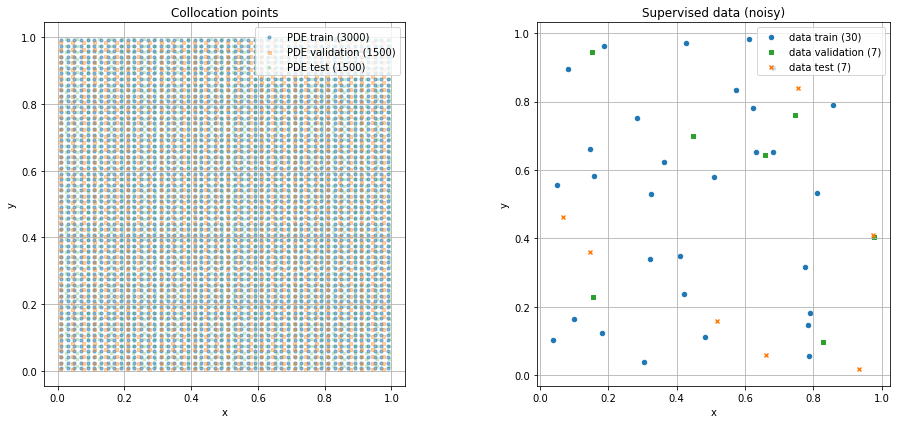

In [32]:
plot_points()


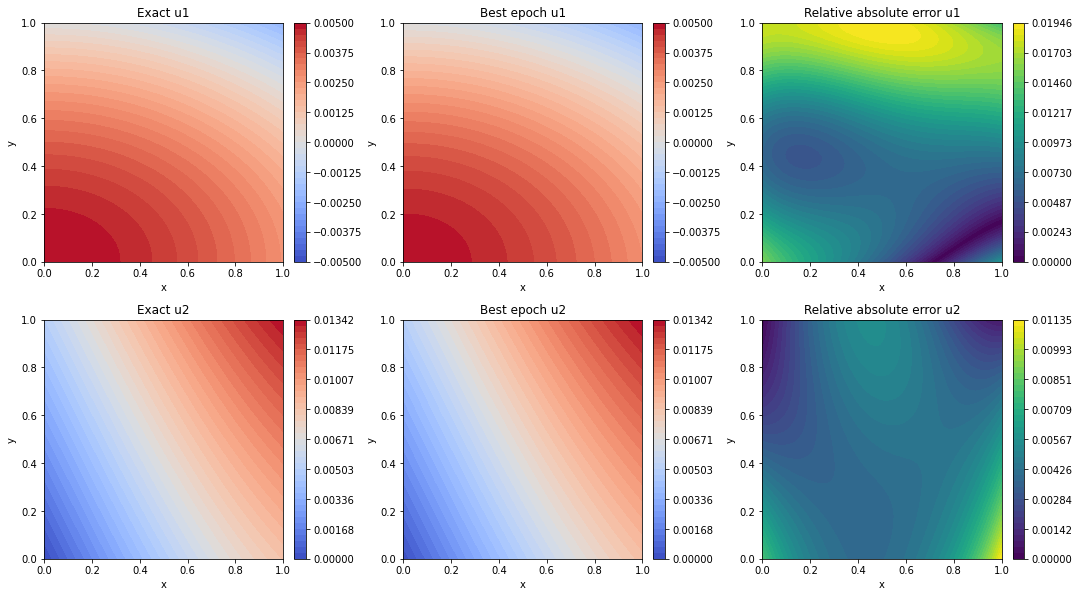

In [33]:
plot_displacement()


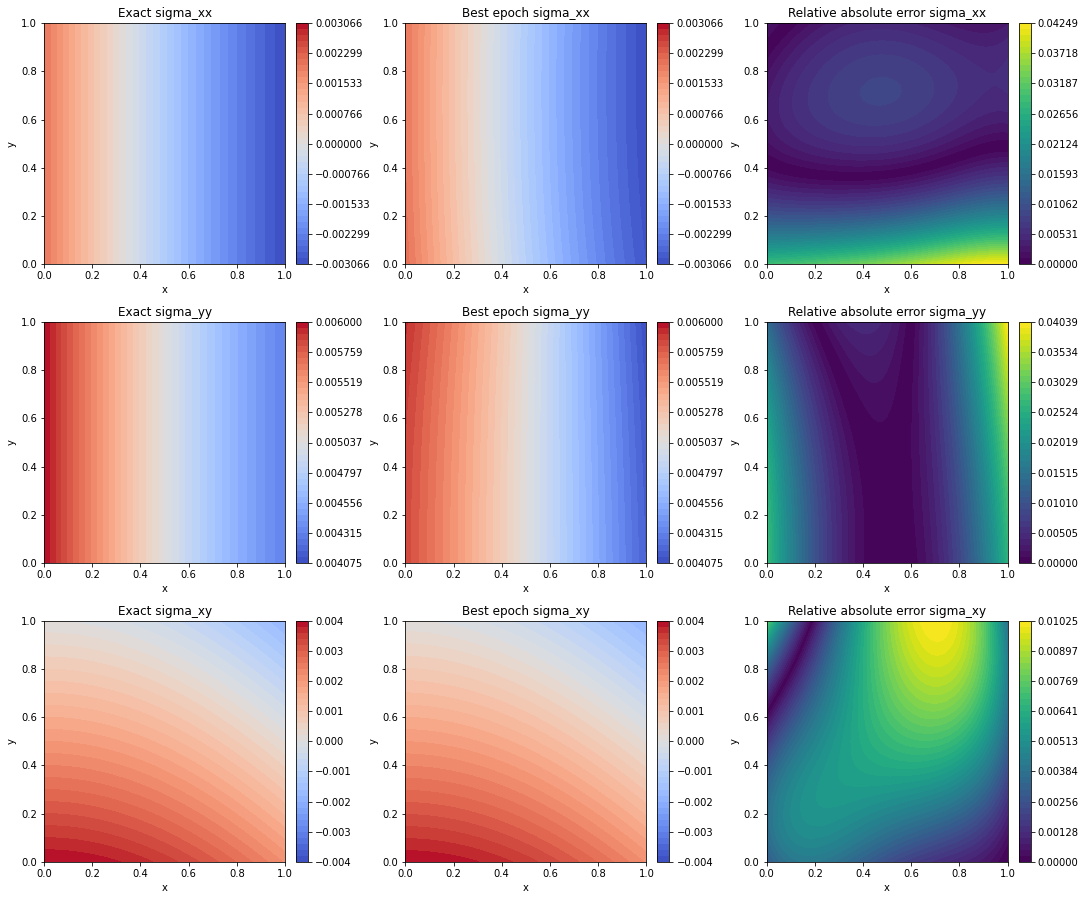

In [34]:
plot_stress()


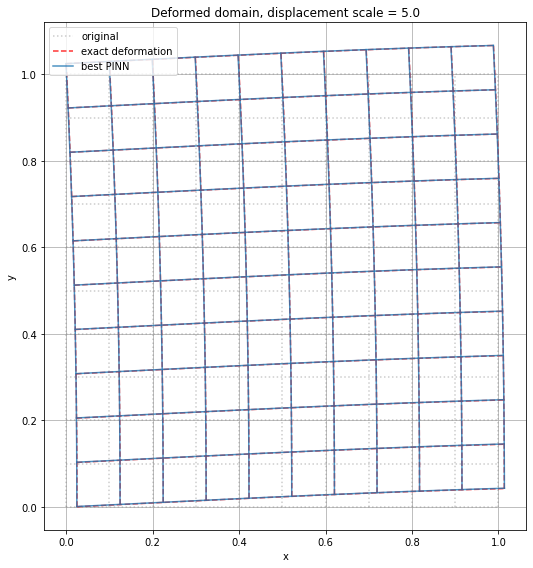

In [35]:
plot_deformed_domain(scale=5.0)


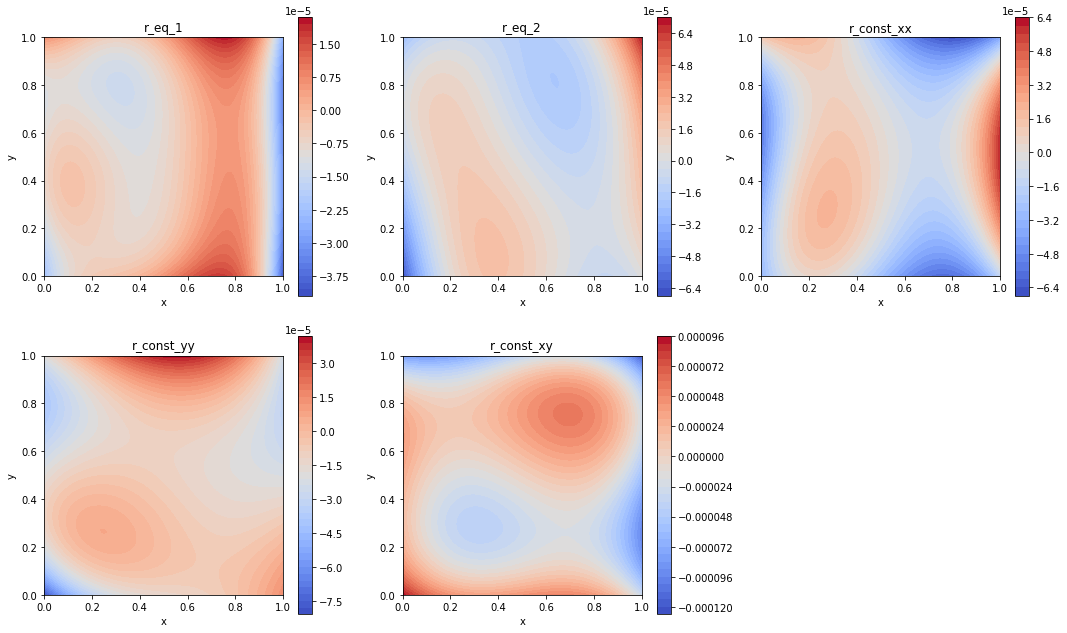

In [36]:
plot_residuals()


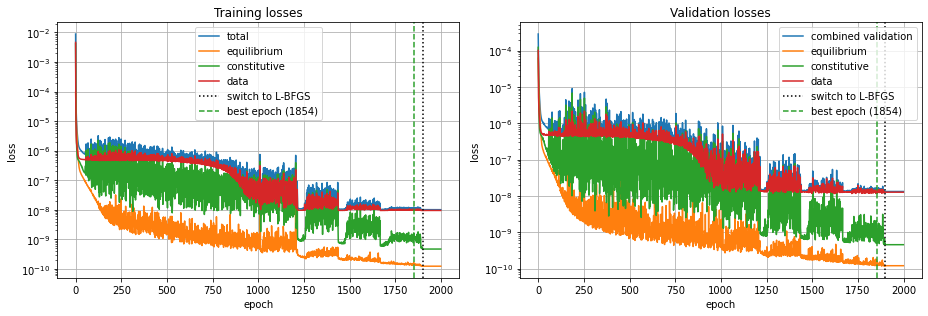

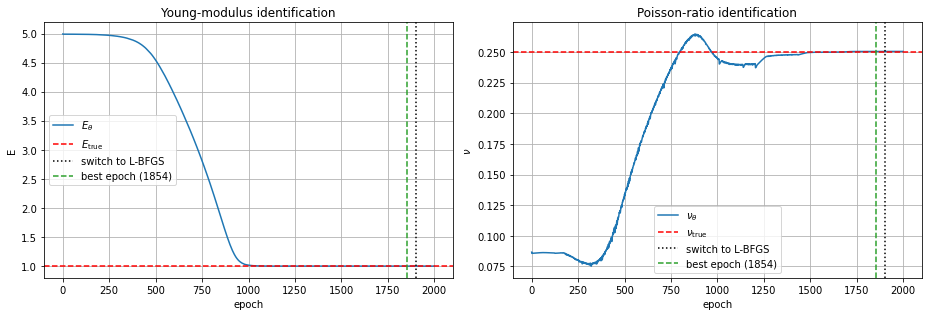

In [37]:
plot_loss()
plot_material_parameters()
